In [559]:
import pandas as pd
import numpy as np
# from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.preprocessing import OrdinalEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [560]:
data = pd.read_csv('./data/Datos Lab 1.csv',sep=",", encoding='utf-8')

In [561]:
df = data.copy()

In [562]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   str    
 1   Date of Service               1639 non-null   str    
 2   Sex                           1639 non-null   str    
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   str    
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   str    
 13  Diabetes Statu

In [563]:
df.describe(include='all')

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
count,1639,1639,1639,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1639,1571.000000,...,1639,1639,1571.000000,1563.000000,1578.000000,1554.000000,1639,1582.000000,1610.000000,1639
unique,1376,1274,2,NaN,NaN,NaN,NaN,NaN,1152,NaN,...,3,2,NaN,NaN,NaN,NaN,4,NaN,NaN,3
top,oSqq7069,09-20-2023,M,NaN,NaN,NaN,NaN,NaN,127/84,NaN,...,High,N,NaN,NaN,NaN,NaN,Hypertension Stage 2,NaN,NaN,HIGH
freq,3,6,821,NaN,NaN,NaN,NaN,NaN,6,NaN,...,582,820,NaN,NaN,NaN,NaN,680,NaN,NaN,793
mean,NaN,NaN,NaN,46.803186,85.666006,1.757439,28.424744,91.538861,NaN,199.043673,...,NaN,NaN,175.770082,0.522440,125.632637,82.887536,NaN,113.235896,18.227281,NaN
std,NaN,NaN,NaN,13.039479,21.712504,0.118012,7.309275,13.427985,NaN,59.388670,...,NaN,NaN,11.695880,0.085692,22.577463,15.503625,NaN,61.435291,10.767666,NaN
min,NaN,NaN,NaN,6.134000,13.261000,1.371000,4.317000,49.542000,NaN,-1.256000,...,NaN,NaN,136.498000,0.250000,49.914000,31.720000,NaN,-92.055000,-20.057000,NaN
25%,NaN,NaN,NaN,37.000000,67.100000,1.666500,22.600000,79.700000,NaN,150.000000,...,NaN,NaN,167.000000,0.453000,108.000000,71.000000,NaN,62.000000,15.150000,NaN
50%,NaN,NaN,NaN,46.000000,86.314000,1.760000,28.000000,91.200000,NaN,199.000000,...,NaN,NaN,176.000000,0.519000,125.000000,82.000000,NaN,112.000000,16.967000,NaN
75%,NaN,NaN,NaN,55.000000,104.801500,1.850000,33.963000,102.267250,NaN,250.000000,...,NaN,NaN,185.000000,0.582000,141.000000,93.000000,NaN,159.000000,18.900000,NaN


In [564]:
df.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


In [565]:
df['Date of Service'] = pd.to_datetime(
    df['Date of Service'],
    format='mixed',
    errors='coerce'
)
df.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,2023-11-08,M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,2024-03-20,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,2022-04-18,F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,2024-01-11,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


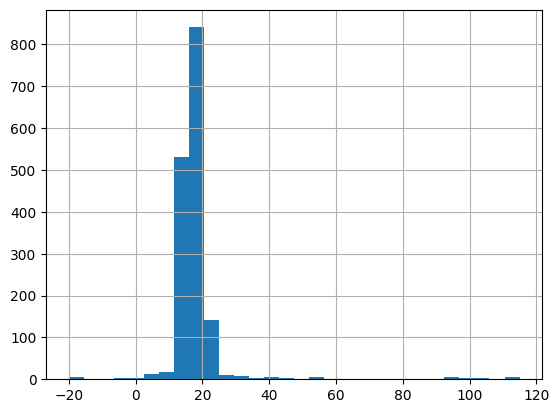

count    1610.000000
mean       18.227281
std        10.767666
min       -20.057000
25%        15.150000
50%        16.967000
75%        18.900000
max       114.980000
Name: CVD Risk Score, dtype: float64


In [566]:
df['CVD Risk Score'].hist(bins=30)
plt.show()
print(df['CVD Risk Score'].describe())

In [567]:
df.drop(columns=['Patient ID'], inplace=True)

In [568]:
ordinales = ['CVD Risk Level', 'Physical Activity Level']
for col in ordinales:
    print(str(col) + ":")
    display(df[col].unique())


CVD Risk Level:


<StringArray>
['HIGH', 'INTERMEDIARY', 'LOW']
Length: 3, dtype: str

Physical Activity Level:


<StringArray>
['High', 'Moderate', 'Low']
Length: 3, dtype: str

In [569]:
for col in ordinales:
    df[col] = (
        df[col]
        .str.lower()
        .str.strip()
        .map({
            'low': 1,
            'moderate': 2,
            'intermediary': 2,
            'high': 3
        })
    )

In [570]:
for col in ordinales:
    print(str(col) + ":")
    display(df[col].unique())

CVD Risk Level:


array([3, 2, 1])

Physical Activity Level:


array([3, 2, 1])

<Axes: >

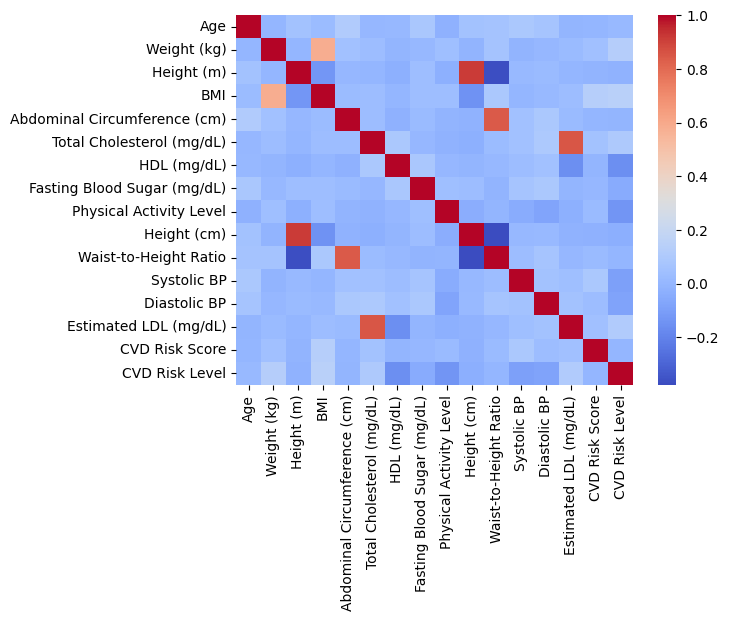

In [571]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

In [572]:
print(df.columns)

Index(['Date of Service', 'Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='str')


In [573]:
cols_to_drop = ['Height (cm)', 'Waist-to-Height Ratio', 'Estimated LDL (mg/dL)', 'Weight (kg)']
df.drop(columns=cols_to_drop, inplace=True)

In [574]:
print(df.columns)

Index(['Date of Service', 'Sex', 'Age', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Systolic BP',
       'Diastolic BP', 'Blood Pressure Category', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='str')


In [575]:
df = df.dropna(subset=['CVD Risk Score'])

In [576]:
print(df['CVD Risk Score'].isna().sum())

0


In [577]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    df[col] = df[col].clip(lower, upper)

In [578]:
X = df.drop('CVD Risk Score', axis=1)
y = df['CVD Risk Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [579]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [580]:
pipeline_lineal = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', Ridge())
])

In [581]:
param_grid = {
    "modelo__alpha" : np.logspace(-4,1.5,25)
}

In [582]:
grid = GridSearchCV(
    estimator=pipeline_lineal,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [583]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'modelo__alpha': array([1.0000...16227766e+01])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

In [584]:
mejor = grid.best_estimator_

In [585]:
y_pred_train = mejor.predict(X_train)
y_pred_test = mejor.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

tabla = pd.DataFrame ({
    "Dataset" : ["Train", "Test"],
    "RMSE" : [rmse_train, rmse_test],
    "MAE" : [mae_train, mae_test],
    "R2" : [r2_train, r2_test]
})
display(tabla)

,Dataset,RMSE,MAE,R2
0,Train,1.956272,0.930069,0.572236
1,Test,2.050071,0.988270,0.548849
